## 3D Gragh for complex structure

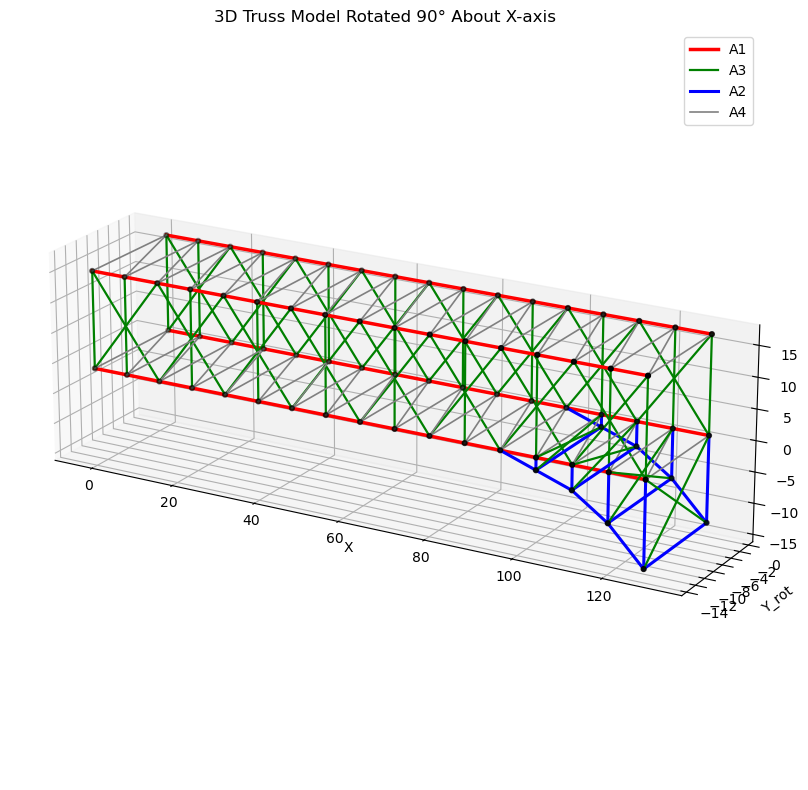

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


with open(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\final_structure.json", "r", encoding="utf-8") as f:
    data = json.load(f)

nodes = data["nodes"]
elements = data["elements"]


def rotate_x_90(p):
    x, y, z = p
    return [x, -z, y]


colors = {
    "A1": "red",    # main chords
    "A2": "blue",   # major web members
    "A3": "green",  # ordinary web members
    "A4": "gray"    # bracing / secondary members
}

linewidths = {
    "A1": 2.5,
    "A2": 2.2,
    "A3": 1.6,
    "A4": 1.2
}


fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

used_labels = set()


for e in elements.values():
    n1, n2, sec = e

    p1 = rotate_x_90(nodes[str(n1)])
    p2 = rotate_x_90(nodes[str(n2)])

    label = sec if sec not in used_labels else None
    used_labels.add(sec)

    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        [p1[2], p2[2]],
        color=colors.get(sec, "black"),
        linewidth=linewidths.get(sec, 1.0),
        label=label
    )


rot_nodes = [rotate_x_90(coord) for coord in nodes.values()]

xs = [p[0] for p in rot_nodes]
ys = [p[1] for p in rot_nodes]
zs = [p[2] for p in rot_nodes]

ax.scatter(xs, ys, zs, s=12, c="black")


ax.set_xlabel("X")
ax.set_ylabel("Y_rot")
ax.set_zlabel("Z_rot")
ax.set_title("3D Truss Model Rotated 90° About X-axis")


ax.set_box_aspect((128, 28, 40))


ax.view_init(elev=20, azim=-60)


ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import json
import plotly.graph_objects as go

# =========================
# 读取 JSON
# =========================
with open(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\final_structure.json", "r", encoding="utf-8") as f:
    data = json.load(f)

nodes = data["nodes"]
elements = data["elements"]


section_names = {
    "A1": "A1 main chords(truss elements)",
    "A2": "A2 Lower Stiffening Member(frame elements)",
    "A3": "A3 ordinary web members(truss elements)",
    "A4": "A4 bracing / secondary(frame elements)"
}

colors = {
    "A1": "red",
    "A2": "blue",
    "A3": "green",
    "A4": "gray"
}

fig = go.Figure()


for sec in ["A1", "A2", "A3", "A4"]:
    xs, ys, zs = [], [], []

    for e in elements.values():
        n1, n2, s = e
        if s != sec:
            continue

        p1 = nodes[str(n1)]
        p2 = nodes[str(n2)]

        xs += [p1[0], p2[0], None]
        ys += [p1[1], p2[1], None]
        zs += [p1[2], p2[2], None]

    fig.add_trace(
        go.Scatter3d(
            x=xs,
            z=ys,
            y=zs,
            mode="lines",
            name=section_names[sec],
            line=dict(
                color=colors[sec],
                width=6 if sec == "A1" else 5 if sec == "A2" else 4 if sec == "A3" else 3
            ),
            hoverinfo="name"
        )
    )


node_ids = sorted(nodes.keys(), key=lambda x: int(x))

node_x = [nodes[k][0] for k in node_ids]
node_y = [nodes[k][1] for k in node_ids]
node_z = [nodes[k][2] for k in node_ids]

fig.add_trace(
    go.Scatter3d(
        x=node_x,
        z=node_y,
        y=node_z,
        mode="markers+text",
        name="Nodes",
        marker=dict(size=3, color="black"),
        text=node_ids,
        textposition="top center",
        textfont=dict(size=8),
        hovertemplate="Node %{text}<br>x=%{x}<br>y=%{y}<br>z=%{z}<extra></extra>"
    )
)


fig.update_layout(
    title="Interactive 3D Truss Model",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="manual",
        aspectratio=dict(x=128, y=40, z=28),
        camera=dict(
            eye=dict(
                x=camera_distance,
                y=-camera_distance,
                z=camera_distance * 0.5
            )
        )
    ),
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.7)"
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)


fig.show()